<a href="https://colab.research.google.com/github/lasyatummalapalli/Assignment-03-bitsom_ba_2511969-Data-Visualization-Machine-Learning/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Students.csv to Students (1).csv


In [14]:
import pandas as pd
df = pd.read_csv("Students (1).csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv("Students (1).csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("=" * 50)
print("STUDENT PERFORMANCE ANALYSIS")
print("=" * 50)

# 1. First 5 rows
print("\n1. FIRST 5 ROWS:")
print(df.head().round(2))

# 2. Dataset info
print("\n2. DATASET INFORMATION:")
print(f"Shape: {df.shape[0]} students × {df.shape[1]} columns")
print("\nData types:")
print(df.dtypes)

# 3. Summary statistics
print("\n3. SUMMARY STATISTICS:")
print(df.describe().round(2))

# 4. Pass/Fail distribution
print("\n4. PASS/FAIL DISTRIBUTION:")
pass_fail = df['passed'].value_counts()
print(pass_fail)
print(f"Pass rate: {(pass_fail[1]/len(df)*100):.1f}%")

# 5. Subject averages by performance
passed_avg = df[df['passed'] == 1][subject_cols].mean()
failed_avg = df[df['passed'] == 0][subject_cols].mean()

print("\n5. AVERAGE SCORES BY PERFORMANCE:")
print("Subject    | Passed  | Failed")
print("-" * 30)
for subject in subject_cols:
    print(f"{subject:9} | {passed_avg[subject]:6.1f} | {failed_avg[subject]:6.1f}")

# 6. Top performing student
df['average'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['average'].idxmax()]
print("\n6. TOP PERFORMING STUDENT:")
print(f"Student ID: {top_student.name}")
print(f"Average: {top_student['average']:.1f}")
print("Scores:", {col: top_student[col] for col in subject_cols})

STUDENT PERFORMANCE ANALYSIS

1. FIRST 5 ROWS:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

2. DATASET INFORMATION:
Shape: 15 students × 9 columns

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtyp

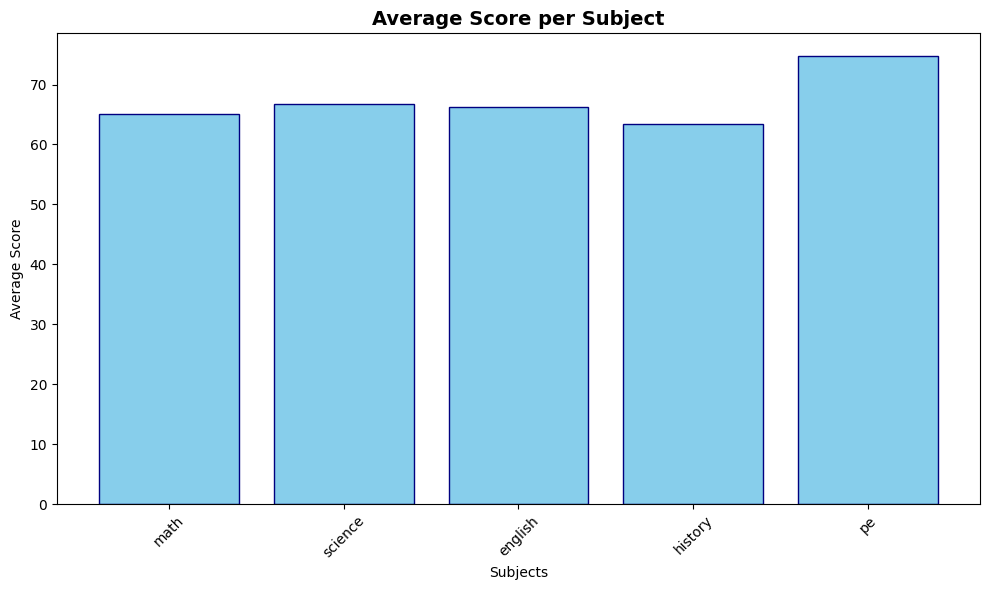

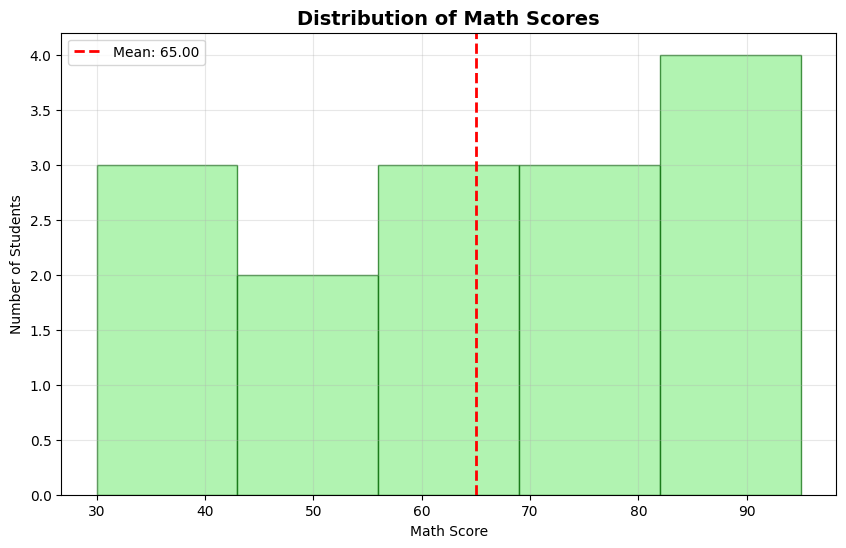

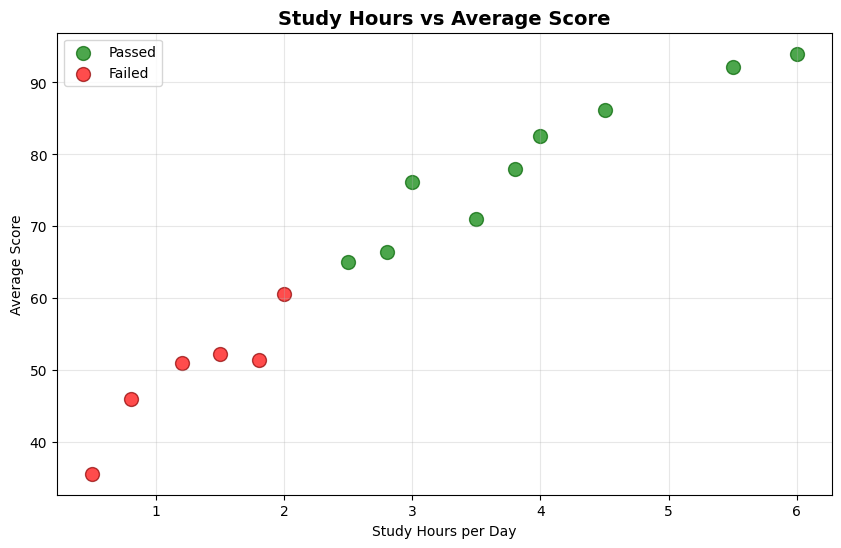

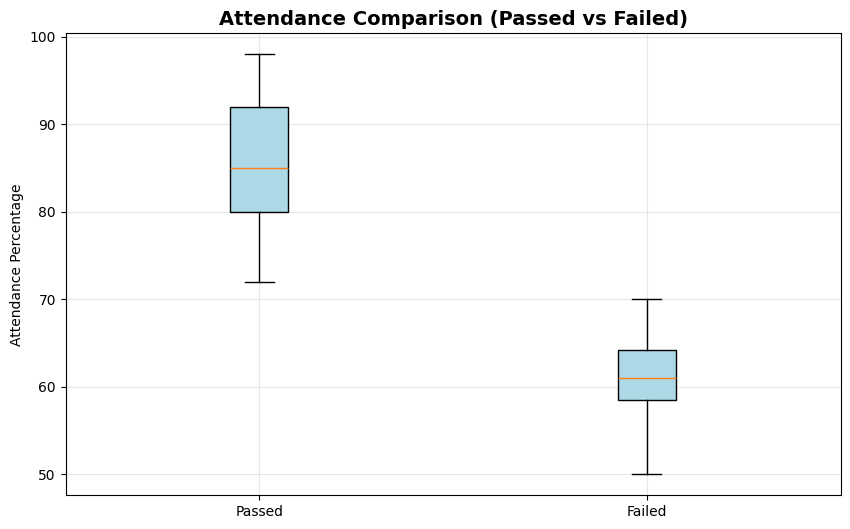

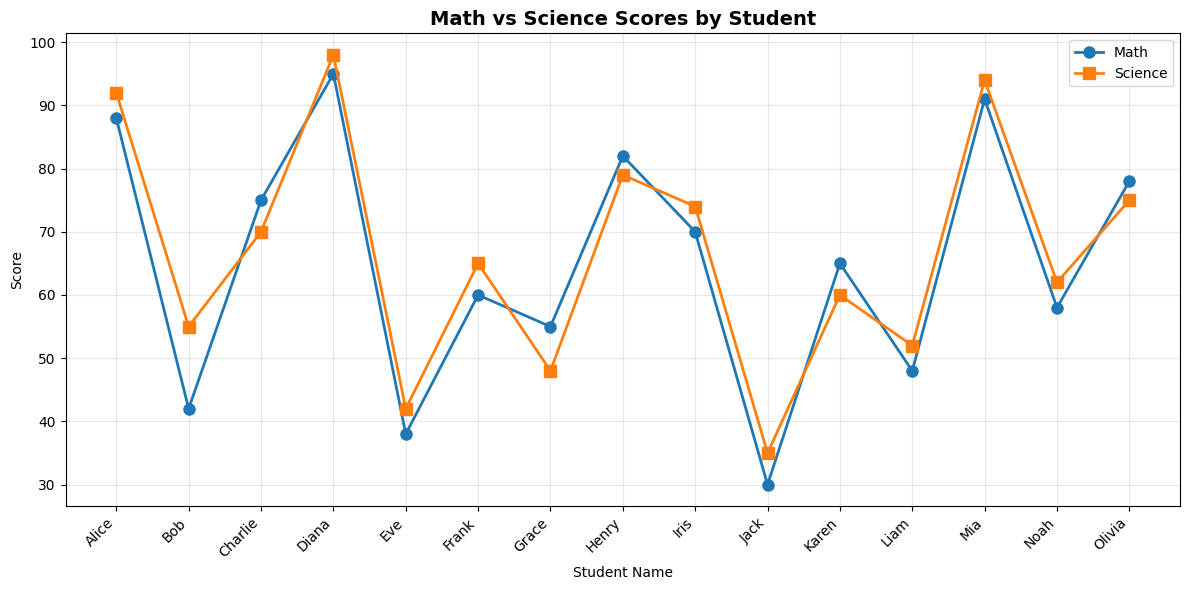

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset and create avg_score column (REQUIRED)
df = pd.read_csv("Students (1).csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. BAR CHART - Average score per subject
plt.figure(figsize=(10, 6))
avg_scores = df[subject_cols].mean()
plt.bar(subject_cols, avg_scores, color='skyblue', edgecolor='navy')
plt.title('Average Score per Subject', fontsize=14, fontweight='bold')
plt.xlabel('Subjects')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot1_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. HISTOGRAM - Math scores distribution
plt.figure(figsize=(10, 6))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='darkgreen', alpha=0.7)
mean_math = df['math'].mean()
plt.axvline(mean_math, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_math:.2f}')
plt.title('Distribution of Math Scores', fontsize=14, fontweight='bold')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot2_hist.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. SCATTER PLOT - Study hours vs avg_score
plt.figure(figsize=(10, 6))
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]
plt.scatter(passed['study_hours_per_day'], passed['avg_score'],
           color='green', s=100, alpha=0.7, label='Passed', edgecolors='darkgreen')
plt.scatter(failed['study_hours_per_day'], failed['avg_score'],
           color='red', s=100, alpha=0.7, label='Failed', edgecolors='darkred')
plt.title('Study Hours vs Average Score', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot3_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. BOX PLOT - Attendance comparison
plt.figure(figsize=(10, 6))
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Passed', 'Failed'],
           patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Attendance Comparison (Passed vs Failed)', fontsize=14, fontweight='bold')
plt.ylabel('Attendance Percentage')
plt.grid(True, alpha=0.3)
plt.savefig('plot4_box.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. LINE PLOT - Math vs Science scores
plt.figure(figsize=(12, 6))
plt.plot(df['name'], df['math'], marker='o', linewidth=2, label='Math', markersize=8)
plt.plot(df['name'], df['science'], marker='s', linewidth=2, label='Science', markersize=8)
plt.title('Math vs Science Scores by Student', fontsize=14, fontweight='bold')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_line.png', dpi=300, bbox_inches='tight')
plt.show()

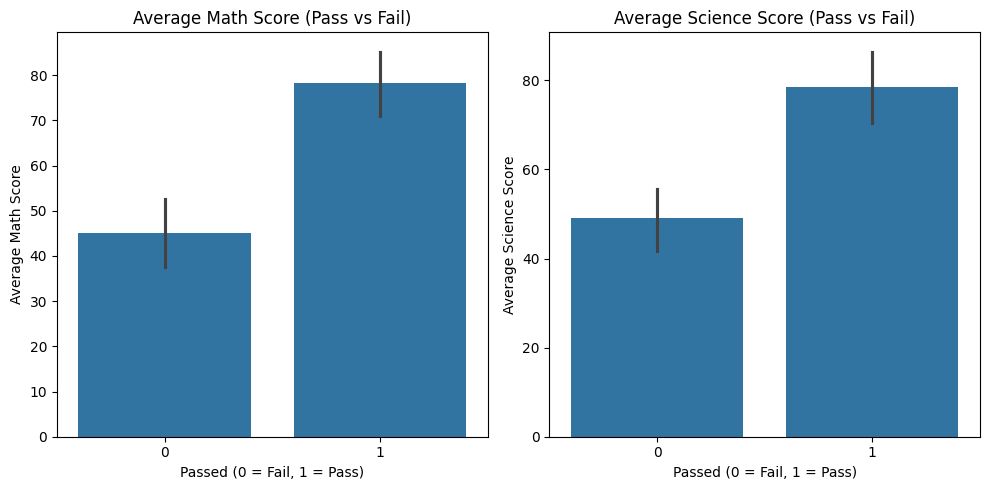

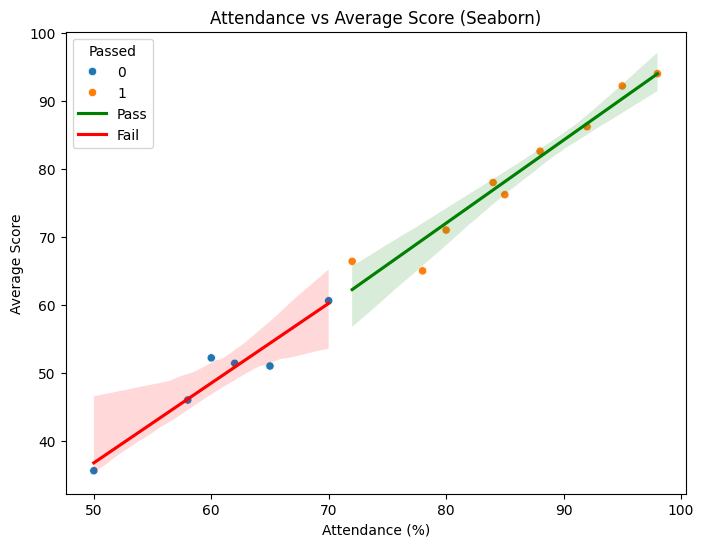

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load data
df = pd.read_csv("Students (1).csv")

# Ensure avg_score exists
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------
# 1. BAR PLOTS (Math & Science)
# -------------------------------
plt.figure(figsize=(10, 5))

# Math bar plot
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Average Math Score")

# Science bar plot
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()

# -------------------------------
# 2. SCATTER + REGRESSION
# -------------------------------
plt.figure(figsize=(8, 6))

# Scatter plot coloured by pass/fail
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines for Pass and Fail
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass',
    color='green'
)
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail',
    color='red'
)

plt.title("Attendance vs Average Score (Seaborn)")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend(title="Passed")

plt.savefig("seaborn_scatter.png")
plt.show()

# -------------------------------
# 3. COMMENT (REQUIRED)
# -------------------------------
# I found Seaborn easier than Matplotlib for these plots because it automatically
# handles grouping, colors, and statistics like the average in bar plots.
# With fewer lines of code, I could create clean and informative visuals,
# especially for comparisons between Pass and Fail groups.

Training Accuracy: 1.0
Test Accuracy: 1.0

Test Predictions:
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

Feature Importance (sorted by |coefficient|):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


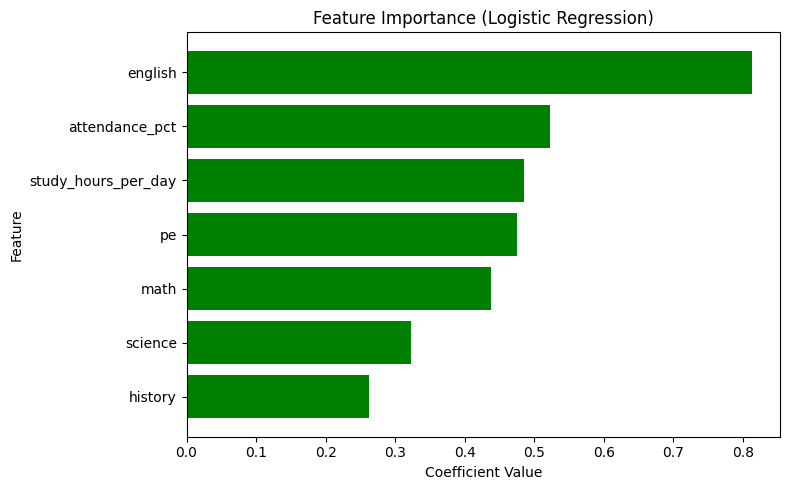


New Student Prediction:
Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------------
# STEP 0 — LOAD DATA
# -------------------------------
df = pd.read_csv("Students (1).csv")

# -------------------------------
# STEP 1 — PREPARE DATA
# -------------------------------
feature_cols = [
    'math', 'science', 'english', 'history', 'pe',
    'attendance_pct', 'study_hours_per_day'
]

# Features and target
X = df[feature_cols]
y = df['passed']

# Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# STEP 2 — TRAIN MODEL
# -------------------------------
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy:", train_acc)

# -------------------------------
# STEP 3 — EVALUATE MODEL
# -------------------------------
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

print("\nTest Predictions:")
for i, idx in enumerate(X_test.index):
    name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    predicted = y_pred[i]
    result = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={predicted} → {result}")

# -------------------------------
# STEP 4 — FEATURE IMPORTANCE
# -------------------------------
coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted by |coefficient|):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

# Plot horizontal bar chart
features = [f for f, _ in feature_importance]
values = [v for _, v in feature_importance]
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure(figsize=(8, 5))
plt.barh(features, values, color=colors)
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# -------------------------------
# STEP 5 — NEW STUDENT PREDICTION
# -------------------------------
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order must match feature_cols

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", result)
print("Probability:", probability)